In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, sosfiltfilt
from scipy.stats import entropy as shannon_entropy
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.cluster import DBSCAN
import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# -----------------------------
# Exact dataset roots on your PC
# -----------------------------
ANES_ROOT = Path(
    r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\20120803PF_Anesthesia+and+Sleep_George_Toru+Yanagawa_mat_ECoG128\20120803PF_Anesthesia+and+Sleep_George_Toru+Yanagawa_mat_ECoG128"
)

FOOD_ROOT = Path(
    r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\20100705S1_Epidural-ECoG+Food-Tracking_B_Kentaro+Shimoda_mat_ECoG64-Motion6\20100705S1_Epidural-ECoG+Food-Tracking_B_Kentaro+Shimoda_mat_ECoG64-Motion6"
)

OUT_ROOT = Path(r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs")
FIG_DIR = OUT_ROOT / "figures"
TAB_DIR = OUT_ROOT / "tables"
MID_DIR = OUT_ROOT / "intermediate"

for p in [OUT_ROOT, FIG_DIR, TAB_DIR, MID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

FS_ECOG = 1000
FS_MOTION = 120
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Anesthesia root exists:", ANES_ROOT.exists())
print("Food root exists:", FOOD_ROOT.exists())
print("Output root:", OUT_ROOT)

Anesthesia root exists: True
Food root exists: True
Output root: C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs


In [2]:
def load_mat(path):
    return sio.loadmat(path, squeeze_me=True, struct_as_record=False)

def get_nonmeta_keys(mat):
    return [k for k in mat.keys() if not k.startswith("__")]

def load_channel_file(path):
    """
    Mirrors your existing repo logic:
    if 'data' exists, use it
    otherwise use the first non-meta variable
    """
    mat = load_mat(path)
    keys = get_nonmeta_keys(mat)
    if "data" in keys:
        x = np.asarray(mat["data"]).squeeze()
    else:
        x = np.asarray(mat[keys[0]]).squeeze()
    return x.astype(float)

def load_vector_file(path):
    mat = load_mat(path)
    keys = get_nonmeta_keys(mat)
    x = np.asarray(mat[keys[0]]).squeeze()
    return x.astype(float)

def bandpass_filter_1_100(x, fs=1000, order=4):
    sos = butter(order, [1, 100], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, x)

def zscore_signal(x):
    sd = np.std(x)
    if sd == 0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / sd

def symbolic_discretize(x, n_bins=6):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1)[1:-1])
    return np.digitize(x, edges)

def epoch_start_times_from_timevec(time_vec, samples_per_epoch):
    n_epochs = len(time_vec) // samples_per_epoch
    return time_vec[: n_epochs * samples_per_epoch : samples_per_epoch]

def compute_channel_epoch_features(ecog_data, epoch_length_sec=2, fs=1000, n_bins=6, alpha=1.0, beta=1.0):
    """
    ecog_data shape = (n_channels, n_timepoints)
    Returns dict with matrices shape (n_channels, n_epochs)
    """
    n_channels, n_timepoints = ecog_data.shape
    samples_per_epoch = int(epoch_length_sec * fs)
    n_epochs = n_timepoints // samples_per_epoch

    curvature_mat = np.zeros((n_channels, n_epochs))
    entropy_mat = np.zeros((n_channels, n_epochs))
    rec_gain_mat = np.zeros((n_channels, n_epochs))
    rms_mat = np.zeros((n_channels, n_epochs))
    meanabs_mat = np.zeros((n_channels, n_epochs))

    for ch in range(n_channels):
        x = ecog_data[ch]
        prev_H = 0.0

        for ep in range(n_epochs):
            segment = x[ep * samples_per_epoch : (ep + 1) * samples_per_epoch]

            symbols = symbolic_discretize(segment, n_bins=n_bins)
            counts = np.bincount(symbols, minlength=n_bins)
            prob = counts / counts.sum()

            H = shannon_entropy(prob, base=np.e)
            rec_gain = mutual_info_score(symbols[:-1], symbols[1:])
            dH = H - prev_H if ep > 0 else 0.0
            K = alpha * rec_gain - beta * dH

            curvature_mat[ch, ep] = K
            entropy_mat[ch, ep] = H
            rec_gain_mat[ch, ep] = rec_gain
            rms_mat[ch, ep] = np.sqrt(np.mean(segment ** 2))
            meanabs_mat[ch, ep] = np.mean(np.abs(segment))

            prev_H = H

    return {
        "ric": curvature_mat,
        "entropy": entropy_mat,
        "rec_gain": rec_gain_mat,
        "rms": rms_mat,
        "meanabs": meanabs_mat,
        "n_epochs": n_epochs,
        "samples_per_epoch": samples_per_epoch
    }

def save_numpy_dict(feature_dict, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    for k, v in feature_dict.items():
        if isinstance(v, np.ndarray):
            np.save(out_dir / f"{k}.npy", v)

def make_single_feature(X_channel_epoch):
    return np.mean(X_channel_epoch, axis=0).reshape(-1, 1)

def make_multichannel_feature(X_channel_epoch):
    return X_channel_epoch.T

def concat_features(*arrays_2d):
    return np.concatenate(arrays_2d, axis=1)

def build_models():
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
    ])

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ])
    return {"LogReg": logreg, "RandomForest": rf}

def evaluate_binary_model(X, y, model, cv=10):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)

    y_pred = cross_val_predict(model, X, y, cv=skf, method="predict")

    try:
        y_score = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
    except Exception:
        y_score = cross_val_predict(model, X, y, cv=skf, method="decision_function")

    return {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "auc": roc_auc_score(y, y_score),
        "confusion_matrix": confusion_matrix(y, y_pred)
    }

def run_feature_benchmarks(dataset_name, y, feature_sets):
    models = build_models()
    rows = []

    for feature_name, X in feature_sets.items():
        for model_name, model in models.items():
            metrics = evaluate_binary_model(X, y, model, cv=10)
            rows.append({
                "dataset": dataset_name,
                "feature_set": feature_name,
                "model": model_name,
                "n_samples": X.shape[0],
                "n_features": X.shape[1],
                "accuracy": metrics["accuracy"],
                "balanced_accuracy": metrics["balanced_accuracy"],
                "f1": metrics["f1"],
                "auc": metrics["auc"]
            })

    return pd.DataFrame(rows)

def run_umap_dbscan(X, y, title, out_png):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=SEED
    )
    emb = reducer.fit_transform(Xs)

    clusterer = DBSCAN(eps=0.8, min_samples=5)
    clusters = clusterer.fit_predict(emb)

    non_noise = clusters != -1
    if np.sum(non_noise) > 5 and len(np.unique(clusters[non_noise])) > 1:
        sil = silhouette_score(emb[non_noise], clusters[non_noise])
        ari = adjusted_rand_score(y[non_noise], clusters[non_noise])
    else:
        sil = np.nan
        ari = np.nan

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sc1 = ax[0].scatter(emb[:, 0], emb[:, 1], c=y, s=16)
    ax[0].set_title(f"{title} — colored by state")

    sc2 = ax[1].scatter(emb[:, 0], emb[:, 1], c=clusters, s=16)
    ax[1].set_title(f"{title} — DBSCAN clusters")

    for a in ax:
        a.set_xlabel("UMAP1")
        a.set_ylabel("UMAP2")

    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight")
    plt.close()

    return {
        "embedding": emb,
        "clusters": clusters,
        "silhouette_non_noise": sil,
        "ari_non_noise": ari
    }

In [7]:
def load_anesthesia_session(session_dir, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    channel_files = [session_dir / f"ECoG_ch{i}.mat" for i in range(1, 129)]
    time_file = session_dir / "ECoGTime.mat"
    cond_file = session_dir / "Condition.mat"

    # Load and preprocess all channels
    all_channels = []
    for f in tqdm(channel_files, desc=f"Loading {session_dir.name} channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)

    # Load time vector
    time_vec = load_vector_file(time_file)

    # Feature extraction
    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    # Load condition file
    mat = load_mat(cond_file)
    ct = np.asarray(mat["ConditionTime"]).squeeze().astype(float)
    cl = [str(x).strip() for x in np.ravel(mat["ConditionLabel"])]

    epoch_times = epoch_start_times_from_timevec(time_vec, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]

    # labels:
    # 0 = unlabeled / excluded
    # 1 = eyes opened
    # 2 = eyes closed
    # 3 = anesthetized
    labels = np.zeros(feats["n_epochs"], dtype=int)

    # Build interval dictionary from Start/End labels
    interval_dict = {}

    for i, lbl in enumerate(cl):
        if lbl.endswith("-Start"):
            base = lbl.replace("-Start", "")
            if i + 1 < len(cl) and cl[i + 1] == f"{base}-End":
                t0 = ct[i]
                t1 = ct[i + 1]
                interval_dict[base] = (t0, t1)

    # Map the intervals we care about
    label_map = {
        "AwakeEyesOpened": 1,
        "RecoveryEyesOpened": 1,
        "AwakeEyesClosed": 2,
        "RecoveryEyesClosed": 2,
        "Anesthetized": 3
    }

    for base_name, code in label_map.items():
        if base_name in interval_dict:
            t0, t1 = interval_dict[base_name]
            labels[(epoch_times >= t0) & (epoch_times < t1)] = code

    # Keep only open/closed epochs for the manuscript benchmark
    keep = np.isin(labels, [1, 2])

    out = {
        "session_name": session_dir.name,
        "ecog_data": ecog_data,
        "time_vec": time_vec,
        "condition_time": ct,
        "condition_label_raw": cl,
        "interval_dict": interval_dict,
        "epoch_times": epoch_times,
        "labels_raw": labels,
        "keep_mask": keep
    }
    out.update(feats)

    return out

In [6]:
for sdir in anes_sessions:
    mat = load_mat(sdir / "Condition.mat")
    print("\n==========", sdir.name, "==========")
    print("Keys:", get_nonmeta_keys(mat))
    print("ConditionTime raw:")
    print(np.asarray(mat["ConditionTime"]).squeeze())

    if "ConditionLabel" in mat:
        print("ConditionLabel raw:")
        print(mat["ConditionLabel"])


========== Session1 ==========
Keys: ['ConditionIndex', 'ConditionTime', 'ConditionLabel']
ConditionTime raw:
[1.134000e+00 9.428090e+02 1.027827e+03 1.969102e+03]
ConditionLabel raw:
['AwakeEyesOpened-Start' 'AwakeEyesOpened-End' 'AwakeEyesClosed-Start'
 'AwakeEyesClosed-End']

========== Session2 ==========
Keys: ['ConditionIndex', 'ConditionTime', 'ConditionLabel']
ConditionTime raw:
[  86.052  615.582 1194.16  2779.646 3680.547]
ConditionLabel raw:
['AnestheticInjection' 'Anesthetized-Start' 'Anesthetized-End'
 'RecoveryEyesClosed-Start' 'RecoveryEyesClosed-End']

========== Session3 ==========
Keys: ['ConditionIndex', 'ConditionTime', 'ConditionLabel']
ConditionTime raw:
[ 39.439 978.378]
ConditionLabel raw:
['RecoveryEyesOpened-Start' 'RecoveryEyesOpened-End']


In [8]:
def load_anesthesia_session(session_dir, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    channel_files = [session_dir / f"ECoG_ch{i}.mat" for i in range(1, 129)]
    time_file = session_dir / "ECoGTime.mat"
    cond_file = session_dir / "Condition.mat"

    # Load and preprocess all channels
    all_channels = []
    for f in tqdm(channel_files, desc=f"Loading {session_dir.name} channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)

    # Load time vector
    time_vec = load_vector_file(time_file)

    # Feature extraction
    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    # Condition labeling exactly as your current repo assumes
    mat = load_mat(cond_file)
    ct = np.asarray(mat["ConditionTime"]).flatten().astype(float)

    cond_labels = None
    if "ConditionLabel" in mat:
        try:
            cond_labels = [str(x) for x in np.ravel(mat["ConditionLabel"])]
        except Exception:
            cond_labels = None

    epoch_times = epoch_start_times_from_timevec(time_vec, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]

    labels = np.zeros(feats["n_epochs"], dtype=int)   # 0 unlabeled, 1 opened, 2 closed

    # Same convention used in your current epochlabel.py
    labels[(epoch_times >= ct[0]) & (epoch_times < ct[1])] = 1
    labels[(epoch_times >= ct[2]) & (epoch_times < ct[3])] = 2

    keep = labels > 0

    out = {
        "session_name": session_dir.name,
        "ecog_data": ecog_data,
        "time_vec": time_vec,
        "condition_time": ct,
        "condition_label_raw": cond_labels,
        "epoch_times": epoch_times,
        "labels_raw": labels,
        "keep_mask": keep
    }
    out.update(feats)

    return out


def load_food_dataset(food_dir, wrist_marker_index=2, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    # ignore __MACOSX junk by using the real inner folder only
    channel_files = [food_dir / f"ECoG_ch{i}.mat" for i in range(1, 65)]
    time_file = food_dir / "ECoG_time.mat"
    motion_file = food_dir / "Motion.mat"

    # Load and preprocess channels
    all_channels = []
    for f in tqdm(channel_files, desc="Loading food-tracking channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)
    time_vec = load_vector_file(time_file)

    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    # Motion handling from your current scripts:
    # MotionData[wrist_marker_index, 0] has marker XYZ with shape ~ (124230, 3)
    mot = load_mat(motion_file)
    MotionData = mot["MotionData"]
    wrist_xyz = MotionData[wrist_marker_index, 0].astype(float)

    speed = np.linalg.norm(np.diff(wrist_xyz, axis=0), axis=1) * FS_MOTION
    speed = np.concatenate(([0.0], speed))
    motion_time = np.arange(len(speed)) / FS_MOTION

    epoch_times = epoch_start_times_from_timevec(time_vec, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]
    epoch_end = epoch_times + epoch_length_sec

    epoch_motion_speed = np.full(feats["n_epochs"], np.nan)

    for i, (t0, t1) in enumerate(zip(epoch_times, epoch_end)):
        mask = (motion_time >= t0) & (motion_time < t1)
        if np.any(mask):
            epoch_motion_speed[i] = np.median(speed[mask])

    valid = ~np.isnan(epoch_motion_speed)
    thr = np.percentile(epoch_motion_speed[valid], 70)

    labels = np.zeros(feats["n_epochs"], dtype=int)   # 0 not moving, 1 moving
    labels[valid & (epoch_motion_speed > thr)] = 1

    out = {
        "session_name": "FoodTracking",
        "ecog_data": ecog_data,
        "time_vec": time_vec,
        "motion_time": motion_time,
        "motion_speed": speed,
        "epoch_times": epoch_times,
        "epoch_motion_speed": epoch_motion_speed,
        "motion_threshold_70": thr,
        "labels_raw": labels,
        "keep_mask": valid
    }
    out.update(feats)

    return out

In [1]:
def load_anesthesia_session_v2(session_dir, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    channel_files = [session_dir / f"ECoG_ch{i}.mat" for i in range(1, 129)]
    time_file = session_dir / "ECoGTime.mat"
    cond_file = session_dir / "Condition.mat"

    # Load and preprocess all channels
    all_channels = []
    for f in tqdm(channel_files, desc=f"Loading {session_dir.name} channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)

    # Load time vector
    time_vec = load_vector_file(time_file)

    # Feature extraction
    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    # Load condition file
    mat = load_mat(cond_file)
    ct = np.asarray(mat["ConditionTime"]).squeeze().astype(float)
    cl = [str(x).strip() for x in np.ravel(mat["ConditionLabel"])]

    epoch_times = epoch_start_times_from_timevec(time_vec, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]

    # 0 = exclude, 1 = eyes opened, 2 = eyes closed, 3 = anesthetized
    labels = np.zeros(feats["n_epochs"], dtype=int)

    # Build intervals from Start/End labels
    interval_dict = {}

    for i, lbl in enumerate(cl):
        if lbl.endswith("-Start"):
            base = lbl.replace("-Start", "")
            if i + 1 < len(cl) and cl[i + 1] == f"{base}-End":
                interval_dict[base] = (ct[i], ct[i + 1])

    # Map intervals to codes
    label_map = {
        "AwakeEyesOpened": 1,
        "RecoveryEyesOpened": 1,
        "AwakeEyesClosed": 2,
        "RecoveryEyesClosed": 2,
        "Anesthetized": 3,
    }

    for base_name, code in label_map.items():
        if base_name in interval_dict:
            t0, t1 = interval_dict[base_name]
            labels[(epoch_times >= t0) & (epoch_times < t1)] = code

    # Keep only opened/closed for manuscript benchmark
    keep = np.isin(labels, [1, 2])

    out = {
        "session_name": session_dir.name,
        "ecog_data": ecog_data,
        "time_vec": time_vec,
        "condition_time": ct,
        "condition_label_raw": cl,
        "interval_dict": interval_dict,
        "epoch_times": epoch_times,
        "labels_raw": labels,
        "keep_mask": keep
    }
    out.update(feats)

    return out

In [2]:
print(load_anesthesia_session_v2.__name__)

load_anesthesia_session_v2


In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, sosfiltfilt
from scipy.stats import entropy as shannon_entropy
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.cluster import DBSCAN
import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ANES_ROOT = Path(
    r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\20120803PF_Anesthesia+and+Sleep_George_Toru+Yanagawa_mat_ECoG128\20120803PF_Anesthesia+and+Sleep_George_Toru+Yanagawa_mat_ECoG128"
)

FOOD_ROOT = Path(
    r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\20100705S1_Epidural-ECoG+Food-Tracking_B_Kentaro+Shimoda_mat_ECoG64-Motion6\20100705S1_Epidural-ECoG+Food-Tracking_B_Kentaro+Shimoda_mat_ECoG64-Motion6"
)

OUT_ROOT = Path(r"C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs")
FIG_DIR = OUT_ROOT / "figures"
TAB_DIR = OUT_ROOT / "tables"
MID_DIR = OUT_ROOT / "intermediate"

for p in [OUT_ROOT, FIG_DIR, TAB_DIR, MID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

FS_ECOG = 1000
FS_MOTION = 120
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("ANES_ROOT exists:", ANES_ROOT.exists())
print("FOOD_ROOT exists:", FOOD_ROOT.exists())

ANES_ROOT exists: True
FOOD_ROOT exists: True


In [5]:
def load_mat(path):
    return sio.loadmat(path, squeeze_me=True, struct_as_record=False)

def get_nonmeta_keys(mat):
    return [k for k in mat.keys() if not k.startswith("__")]

def load_channel_file(path):
    mat = load_mat(path)
    keys = get_nonmeta_keys(mat)
    if "data" in keys:
        x = np.asarray(mat["data"]).squeeze()
    else:
        x = np.asarray(mat[keys[0]]).squeeze()
    return x.astype(float)

def load_vector_file(path):
    mat = load_mat(path)
    keys = get_nonmeta_keys(mat)
    x = np.asarray(mat[keys[0]]).squeeze()
    return x.astype(float)

def bandpass_filter_1_100(x, fs=1000, order=4):
    sos = butter(order, [1, 100], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, x)

def zscore_signal(x):
    sd = np.std(x)
    if sd == 0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / sd

def symbolic_discretize(x, n_bins=6):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1)[1:-1])
    return np.digitize(x, edges)

def epoch_start_times_from_timevec(time_vec, samples_per_epoch):
    n_epochs = len(time_vec) // samples_per_epoch
    return time_vec[: n_epochs * samples_per_epoch : samples_per_epoch]

def compute_channel_epoch_features(ecog_data, epoch_length_sec=2, fs=1000, n_bins=6, alpha=1.0, beta=1.0):
    n_channels, n_timepoints = ecog_data.shape
    samples_per_epoch = int(epoch_length_sec * fs)
    n_epochs = n_timepoints // samples_per_epoch

    curvature_mat = np.zeros((n_channels, n_epochs))
    entropy_mat = np.zeros((n_channels, n_epochs))
    rec_gain_mat = np.zeros((n_channels, n_epochs))
    rms_mat = np.zeros((n_channels, n_epochs))
    meanabs_mat = np.zeros((n_channels, n_epochs))

    for ch in range(n_channels):
        x = ecog_data[ch]
        prev_H = 0.0

        for ep in range(n_epochs):
            segment = x[ep * samples_per_epoch : (ep + 1) * samples_per_epoch]

            symbols = symbolic_discretize(segment, n_bins=n_bins)
            counts = np.bincount(symbols, minlength=n_bins)
            prob = counts / counts.sum()

            H = shannon_entropy(prob, base=np.e)
            rec_gain = mutual_info_score(symbols[:-1], symbols[1:])
            dH = H - prev_H if ep > 0 else 0.0
            K = alpha * rec_gain - beta * dH

            curvature_mat[ch, ep] = K
            entropy_mat[ch, ep] = H
            rec_gain_mat[ch, ep] = rec_gain
            rms_mat[ch, ep] = np.sqrt(np.mean(segment ** 2))
            meanabs_mat[ch, ep] = np.mean(np.abs(segment))

            prev_H = H

    return {
        "ric": curvature_mat,
        "entropy": entropy_mat,
        "rec_gain": rec_gain_mat,
        "rms": rms_mat,
        "meanabs": meanabs_mat,
        "n_epochs": n_epochs,
        "samples_per_epoch": samples_per_epoch
    }

def save_numpy_dict(feature_dict, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    for k, v in feature_dict.items():
        if isinstance(v, np.ndarray):
            np.save(out_dir / f"{k}.npy", v)

def make_single_feature(X_channel_epoch):
    return np.mean(X_channel_epoch, axis=0).reshape(-1, 1)

def make_multichannel_feature(X_channel_epoch):
    return X_channel_epoch.T

def concat_features(*arrays_2d):
    return np.concatenate(arrays_2d, axis=1)

def build_models():
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
    ])

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ])
    return {"LogReg": logreg, "RandomForest": rf}

In [6]:
def load_anesthesia_session_v2(session_dir, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    channel_files = [session_dir / f"ECoG_ch{i}.mat" for i in range(1, 129)]
    time_file = session_dir / "ECoGTime.mat"
    cond_file = session_dir / "Condition.mat"

    all_channels = []
    for f in tqdm(channel_files, desc=f"Loading {session_dir.name} channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)
    time_vec = load_vector_file(time_file)

    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    mat = load_mat(cond_file)
    ct = np.asarray(mat["ConditionTime"]).squeeze().astype(float)
    cl = [str(x).strip() for x in np.ravel(mat["ConditionLabel"])]

    epoch_times = epoch_start_times_from_timevec(time_vec, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]

    labels = np.zeros(feats["n_epochs"], dtype=int)

    interval_dict = {}
    for i, lbl in enumerate(cl):
        if lbl.endswith("-Start"):
            base = lbl.replace("-Start", "")
            if i + 1 < len(cl) and cl[i + 1] == f"{base}-End":
                interval_dict[base] = (ct[i], ct[i + 1])

    label_map = {
        "AwakeEyesOpened": 1,
        "RecoveryEyesOpened": 1,
        "AwakeEyesClosed": 2,
        "RecoveryEyesClosed": 2,
        "Anesthetized": 3,
    }

    for base_name, code in label_map.items():
        if base_name in interval_dict:
            t0, t1 = interval_dict[base_name]
            labels[(epoch_times >= t0) & (epoch_times < t1)] = code

    keep = np.isin(labels, [1, 2])

    out = {
        "session_name": session_dir.name,
        "ecog_data": ecog_data,
        "time_vec": time_vec,
        "condition_time": ct,
        "condition_label_raw": cl,
        "interval_dict": interval_dict,
        "epoch_times": epoch_times,
        "labels_raw": labels,
        "keep_mask": keep
    }
    out.update(feats)

    return out

In [7]:
anes_sessions = [ANES_ROOT / "Session1", ANES_ROOT / "Session2", ANES_ROOT / "Session3"]

anes_results = []
for sdir in anes_sessions:
    res = load_anesthesia_session_v2(
        sdir,
        epoch_length_sec=2,
        n_bins=6,
        alpha=1.0,
        beta=1.0
    )
    anes_results.append(res)

print("Loaded anesthesia sessions:", [r["session_name"] for r in anes_results])

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading Session2 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading Session3 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loaded anesthesia sessions: ['Session1', 'Session2', 'Session3']


In [8]:
for r in anes_results:
    print("\n==========", r["session_name"], "==========")
    print("Intervals found:", r["interval_dict"])
    print("Opened epochs:", np.sum(r["labels_raw"] == 1))
    print("Closed epochs:", np.sum(r["labels_raw"] == 2))
    print("Anesthetized epochs:", np.sum(r["labels_raw"] == 3))
    print("Kept epochs:", np.sum(r["keep_mask"]))


========== Session1 ==========
Intervals found: {'AwakeEyesOpened': (np.float64(1.134), np.float64(942.809)), 'AwakeEyesClosed': (np.float64(1027.827), np.float64(1969.102))}
Opened epochs: 471
Closed epochs: 471
Anesthetized epochs: 0
Kept epochs: 942

========== Session2 ==========
Intervals found: {'Anesthetized': (np.float64(615.582), np.float64(1194.16)), 'RecoveryEyesClosed': (np.float64(2779.646), np.float64(3680.547))}
Opened epochs: 0
Closed epochs: 450
Anesthetized epochs: 290
Kept epochs: 450

========== Session3 ==========
Intervals found: {'RecoveryEyesOpened': (np.float64(39.439), np.float64(978.378))}
Opened epochs: 469
Closed epochs: 0
Anesthetized epochs: 0
Kept epochs: 469


In [9]:
# Primary benchmark: Session1 only (cleanest open vs closed)
anes_session1 = anes_results[0]

anesthesia_primary = {
    "ric": anes_session1["ric"][:, anes_session1["keep_mask"]],
    "entropy": anes_session1["entropy"][:, anes_session1["keep_mask"]],
    "rec_gain": anes_session1["rec_gain"][:, anes_session1["keep_mask"]],
    "rms": anes_session1["rms"][:, anes_session1["keep_mask"]],
    "meanabs": anes_session1["meanabs"][:, anes_session1["keep_mask"]],
    "y": (anes_session1["labels_raw"][anes_session1["keep_mask"]] == 2).astype(int),  # 0=open, 1=closed
    "session": np.array(["Session1"] * np.sum(anes_session1["keep_mask"]))
}

print("Primary anesthesia benchmark")
print("Samples:", anesthesia_primary["ric"].shape[1])
print("Opened:", np.sum(anesthesia_primary["y"] == 0))
print("Closed:", np.sum(anesthesia_primary["y"] == 1))


# Secondary benchmark: recovery only
# Session2 contributes closed, Session3 contributes opened
rec_s2 = anes_results[1]
rec_s3 = anes_results[2]

s2_keep_closed = rec_s2["labels_raw"] == 2
s3_keep_open = rec_s3["labels_raw"] == 1

anesthesia_recovery = {
    "ric": np.concatenate([
        rec_s3["ric"][:, s3_keep_open],   # opened
        rec_s2["ric"][:, s2_keep_closed]  # closed
    ], axis=1),

    "entropy": np.concatenate([
        rec_s3["entropy"][:, s3_keep_open],
        rec_s2["entropy"][:, s2_keep_closed]
    ], axis=1),

    "rec_gain": np.concatenate([
        rec_s3["rec_gain"][:, s3_keep_open],
        rec_s2["rec_gain"][:, s2_keep_closed]
    ], axis=1),

    "rms": np.concatenate([
        rec_s3["rms"][:, s3_keep_open],
        rec_s2["rms"][:, s2_keep_closed]
    ], axis=1),

    "meanabs": np.concatenate([
        rec_s3["meanabs"][:, s3_keep_open],
        rec_s2["meanabs"][:, s2_keep_closed]
    ], axis=1),

    "y": np.concatenate([
        np.zeros(np.sum(s3_keep_open), dtype=int),  # opened
        np.ones(np.sum(s2_keep_closed), dtype=int)  # closed
    ]),

    "session": np.concatenate([
        np.array(["Session3"] * np.sum(s3_keep_open)),
        np.array(["Session2"] * np.sum(s2_keep_closed))
    ])
}

print("\nRecovery anesthesia benchmark")
print("Samples:", anesthesia_recovery["ric"].shape[1])
print("Opened:", np.sum(anesthesia_recovery["y"] == 0))
print("Closed:", np.sum(anesthesia_recovery["y"] == 1))

Primary anesthesia benchmark
Samples: 942
Opened: 471
Closed: 471

Recovery anesthesia benchmark
Samples: 919
Opened: 469
Closed: 450


In [10]:
food_motion_mat = load_mat(FOOD_ROOT / "Motion.mat")
print(get_nonmeta_keys(food_motion_mat))

for k in get_nonmeta_keys(food_motion_mat):
    try:
        arr = np.asarray(food_motion_mat[k])
        print(k, "shape:", arr.shape, "dtype:", arr.dtype)
    except Exception as e:
        print(k, "could not print shape:", e)

['MotionData', 'MotionTime']
MotionData shape: (6,) dtype: object
MotionTime shape: (124230,) dtype: float64


In [11]:
food_time_mat = load_mat(FOOD_ROOT / "ECoG_time.mat")
print(get_nonmeta_keys(food_time_mat))

for k in get_nonmeta_keys(food_time_mat):
    arr = np.asarray(food_time_mat[k])
    print(k, "shape:", arr.shape, "dtype:", arr.dtype)

['ECoGTime']
ECoGTime shape: (1036235,) dtype: float64


In [12]:
food_ch1_mat = load_mat(FOOD_ROOT / "ECoG_ch1.mat")
print(get_nonmeta_keys(food_ch1_mat))

for k in get_nonmeta_keys(food_ch1_mat):
    arr = np.asarray(food_ch1_mat[k])
    print(k, "shape:", arr.shape, "dtype:", arr.dtype)

['ECoGData_ch1']
ECoGData_ch1 shape: (1036235,) dtype: int16


In [13]:
def unwrap_numeric_array(obj):
    """
    Recursively unwrap MATLAB object containers until a numeric ndarray is found.
    """
    if isinstance(obj, np.ndarray):
        if obj.dtype != object and np.issubdtype(obj.dtype, np.number):
            return np.asarray(obj)

        if obj.dtype == object:
            if obj.size == 1:
                return unwrap_numeric_array(obj.item())

            candidates = []
            for item in obj.ravel():
                try:
                    arr = unwrap_numeric_array(item)
                    candidates.append(arr)
                except Exception:
                    pass

            if len(candidates) == 0:
                raise ValueError("Could not unwrap numeric array from object ndarray.")

            candidates = sorted(candidates, key=lambda a: np.prod(a.shape), reverse=True)
            return np.asarray(candidates[0])

    if isinstance(obj, (list, tuple)):
        candidates = []
        for item in obj:
            try:
                arr = unwrap_numeric_array(item)
                candidates.append(arr)
            except Exception:
                pass

        if len(candidates) == 0:
            raise ValueError("Could not unwrap numeric array from list/tuple.")

        candidates = sorted(candidates, key=lambda a: np.prod(a.shape), reverse=True)
        return np.asarray(candidates[0])

    if hasattr(obj, "__dict__"):
        candidates = []
        for _, v in obj.__dict__.items():
            try:
                arr = unwrap_numeric_array(v)
                candidates.append(arr)
            except Exception:
                pass

        if len(candidates) == 0:
            raise ValueError("Could not unwrap numeric array from MATLAB struct-like object.")

        candidates = sorted(candidates, key=lambda a: np.prod(a.shape), reverse=True)
        return np.asarray(candidates[0])

    raise ValueError(f"Unsupported object type for unwrapping: {type(obj)}")

In [14]:
def load_food_dataset_v2(food_dir, wrist_marker_index=2, epoch_length_sec=2, n_bins=6, alpha=1.0, beta=1.0):
    channel_files = [food_dir / f"ECoG_ch{i}.mat" for i in range(1, 65)]
    time_file = food_dir / "ECoG_time.mat"
    motion_file = food_dir / "Motion.mat"

    # Load and preprocess ECoG
    all_channels = []
    for f in tqdm(channel_files, desc="Loading food-tracking channels"):
        x = load_channel_file(f)
        x = bandpass_filter_1_100(x, fs=FS_ECOG, order=4)
        x = zscore_signal(x)
        all_channels.append(x)

    ecog_data = np.vstack(all_channels)
    ecog_time = load_vector_file(time_file)

    feats = compute_channel_epoch_features(
        ecog_data,
        epoch_length_sec=epoch_length_sec,
        fs=FS_ECOG,
        n_bins=n_bins,
        alpha=alpha,
        beta=beta
    )

    # Load motion
    mot = load_mat(motion_file)
    MotionData = mot["MotionData"]
    MotionTime = np.asarray(mot["MotionTime"]).squeeze().astype(float)

    wrist_xyz = unwrap_numeric_array(MotionData[wrist_marker_index])
    wrist_xyz = np.asarray(wrist_xyz, dtype=float).squeeze()

    # Force shape to (N, 3)
    if wrist_xyz.ndim == 1:
        if wrist_xyz.size % 3 != 0:
            raise ValueError(f"Wrist marker cannot be reshaped to Nx3, shape={wrist_xyz.shape}")
        wrist_xyz = wrist_xyz.reshape(-1, 3)

    if wrist_xyz.ndim == 2 and wrist_xyz.shape[1] != 3 and wrist_xyz.shape[0] == 3:
        wrist_xyz = wrist_xyz.T

    if wrist_xyz.ndim != 2 or wrist_xyz.shape[1] != 3:
        raise ValueError(f"Unexpected wrist marker shape after unwrapping: {wrist_xyz.shape}")

    # Align motion arrays
    n_motion = min(len(MotionTime), wrist_xyz.shape[0])
    MotionTime = MotionTime[:n_motion]
    wrist_xyz = wrist_xyz[:n_motion]

    # Compute speed using actual motion timestamps
    dxyz = np.diff(wrist_xyz, axis=0)
    dt = np.diff(MotionTime)

    positive_dt = dt[dt > 0]
    if len(positive_dt) == 0:
        raise ValueError("MotionTime has no positive time differences.")
    dt[dt <= 0] = np.median(positive_dt)

    speed = np.linalg.norm(dxyz, axis=1) / dt
    speed = np.concatenate([[0.0], speed])

    # Epoch-level motion summary aligned to ECoG epochs
    epoch_times = epoch_start_times_from_timevec(ecog_time, feats["samples_per_epoch"])
    epoch_times = epoch_times[:feats["n_epochs"]]
    epoch_end = epoch_times + epoch_length_sec

    epoch_motion_speed = np.full(feats["n_epochs"], np.nan)

    for i, (t0, t1) in enumerate(zip(epoch_times, epoch_end)):
        mask = (MotionTime >= t0) & (MotionTime < t1)
        if np.any(mask):
            epoch_motion_speed[i] = np.median(speed[mask])

    valid = ~np.isnan(epoch_motion_speed)

    # Binary movement label using the 70th percentile of valid epoch speeds
    thr = np.percentile(epoch_motion_speed[valid], 70)

    labels = np.zeros(feats["n_epochs"], dtype=int)   # 0 = not moving
    labels[valid & (epoch_motion_speed > thr)] = 1    # 1 = moving

    out = {
        "session_name": "FoodTracking",
        "ecog_data": ecog_data,
        "ecog_time": ecog_time,
        "motion_time": MotionTime,
        "wrist_xyz": wrist_xyz,
        "motion_speed": speed,
        "epoch_times": epoch_times,
        "epoch_motion_speed": epoch_motion_speed,
        "motion_threshold_70": thr,
        "labels_raw": labels,
        "keep_mask": valid
    }
    out.update(feats)

    return out

In [15]:
food_results = load_food_dataset_v2(
    FOOD_ROOT,
    wrist_marker_index=2,
    epoch_length_sec=2,
    n_bins=6,
    alpha=1.0,
    beta=1.0
)

print("FoodTracking loaded")
print("ECoG data shape:", food_results["ecog_data"].shape)
print("Wrist XYZ shape:", food_results["wrist_xyz"].shape)
print("Motion time length:", len(food_results["motion_time"]))
print("Epoch count:", food_results["ric"].shape[1])
print("Valid motion-aligned epochs:", np.sum(food_results["keep_mask"]))
print("Not moving epochs:", np.sum(food_results["labels_raw"][food_results["keep_mask"]] == 0))
print("Moving epochs:", np.sum(food_results["labels_raw"][food_results["keep_mask"]] == 1))
print("70th percentile threshold:", food_results["motion_threshold_70"])

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

FoodTracking loaded
ECoG data shape: (64, 1036235)
Wrist XYZ shape: (124230, 3)
Motion time length: 124230
Epoch count: 518
Valid motion-aligned epochs: 518
Not moving epochs: 362
Moving epochs: 156
70th percentile threshold: 6.0599763238134035


In [16]:
food_keep = food_results["keep_mask"]

food_all = {
    "ric": food_results["ric"][:, food_keep],
    "entropy": food_results["entropy"][:, food_keep],
    "rec_gain": food_results["rec_gain"][:, food_keep],
    "rms": food_results["rms"][:, food_keep],
    "meanabs": food_results["meanabs"][:, food_keep],
    "y": food_results["labels_raw"][food_keep].astype(int)
}

print("Anesthesia primary shape:", anesthesia_primary["ric"].shape)
print("Food shape:", food_all["ric"].shape)

Anesthesia primary shape: (128, 942)
Food shape: (64, 518)


In [17]:
food_keep = food_results["keep_mask"]

food_all = {
    "ric": food_results["ric"][:, food_keep],
    "entropy": food_results["entropy"][:, food_keep],
    "rec_gain": food_results["rec_gain"][:, food_keep],
    "rms": food_results["rms"][:, food_keep],
    "meanabs": food_results["meanabs"][:, food_keep],
    "y": food_results["labels_raw"][food_keep].astype(int)
}

print("Anesthesia primary shape:", anesthesia_primary["ric"].shape)
print("Food shape:", food_all["ric"].shape)

Anesthesia primary shape: (128, 942)
Food shape: (64, 518)


In [18]:
def make_feature_sets(data_dict):
    ric_mc = make_multichannel_feature(data_dict["ric"])
    ent_mc = make_multichannel_feature(data_dict["entropy"])
    rg_mc = make_multichannel_feature(data_dict["rec_gain"])
    rms_mc = make_multichannel_feature(data_dict["rms"])

    feature_sets = {
        "Mean_RIC": make_single_feature(data_dict["ric"]),
        "Mean_Entropy": make_single_feature(data_dict["entropy"]),
        "Mean_RecGain": make_single_feature(data_dict["rec_gain"]),
        "Mean_RMS": make_single_feature(data_dict["rms"]),
        "RIC_Multichannel": ric_mc,
        "Entropy_Multichannel": ent_mc,
        "RecGain_Multichannel": rg_mc,
        "RMS_Multichannel": rms_mc,
        "RIC_plus_RMS": concat_features(ric_mc, rms_mc),
        "Entropy_plus_RecGain": concat_features(ent_mc, rg_mc),
        "RIC_plus_Entropy_plus_RecGain": concat_features(ric_mc, ent_mc, rg_mc),
    }
    return feature_sets

def evaluate_binary_model(X, y, model, cv=10):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)

    y_pred = cross_val_predict(model, X, y, cv=skf, method="predict")

    try:
        y_score = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
    except Exception:
        y_score = cross_val_predict(model, X, y, cv=skf, method="decision_function")

    return {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "auc": roc_auc_score(y, y_score),
        "confusion_matrix": confusion_matrix(y, y_pred)
    }

def run_feature_benchmarks(dataset_name, y, feature_sets):
    models = build_models()
    rows = []

    for feature_name, X in feature_sets.items():
        for model_name, model in models.items():
            metrics = evaluate_binary_model(X, y, model, cv=10)
            rows.append({
                "dataset": dataset_name,
                "feature_set": feature_name,
                "model": model_name,
                "n_samples": X.shape[0],
                "n_features": X.shape[1],
                "accuracy": metrics["accuracy"],
                "balanced_accuracy": metrics["balanced_accuracy"],
                "f1": metrics["f1"],
                "auc": metrics["auc"]
            })

    return pd.DataFrame(rows)

anes_feature_sets = make_feature_sets(anesthesia_primary)
food_feature_sets = make_feature_sets(food_all)

bench_anes = run_feature_benchmarks(
    "Anesthesia_Session1_Open_vs_Closed",
    anesthesia_primary["y"],
    anes_feature_sets
)

bench_food = run_feature_benchmarks(
    "Food_Moving_vs_NotMoving",
    food_all["y"],
    food_feature_sets
)

bench_df = pd.concat([bench_anes, bench_food], ignore_index=True)
bench_df.to_csv(TAB_DIR / "benchmark_results.csv", index=False)

bench_df.sort_values(["dataset", "auc", "accuracy"], ascending=[True, False, False]).head(30)

,dataset,feature_set,model,n_samples,n_features,accuracy,balanced_accuracy,f1,auc
17,Anesthesia_Session1_Open_vs_Closed,RIC_plus_RMS,RandomForest,942,256,0.985138,0.985138,0.985106,0.998936
19,Anesthesia_Session1_Open_vs_Closed,Entropy_plus_RecGain,RandomForest,942,256,0.983015,0.983015,0.982979,0.998109
9,Anesthesia_Session1_Open_vs_Closed,RIC_Multichannel,RandomForest,942,128,0.979830,0.979830,0.979809,0.998098
13,Anesthesia_Session1_Open_vs_Closed,RecGain_Multichannel,RandomForest,942,128,0.979830,0.979830,0.979809,0.998098
21,Anesthesia_Session1_Open_vs_Closed,RIC_plus_Entropy_plus_RecGain,RandomForest,942,384,0.981953,0.981953,0.981934,0.998080
16,Anesthesia_Session1_Open_vs_Closed,RIC_plus_RMS,LogReg,942,256,0.997877,0.997877,0.997872,0.997886
20,Anesthesia_Session1_Open_vs_Closed,RIC_plus_Entropy_plus_RecGain,LogReg,942,384,0.987261,0.987261,0.987261,0.997638
8,Anesthesia_Session1_Open_vs_Closed,RIC_Multichannel,LogReg,942,128,0.987261,0.987261,0.987261,0.997593
12,Anesthesia_Session1_Open_vs_Closed,RecGain_Multichannel,LogReg,942,128,0.987261,0.987261,0.987261,0.997593
18,Anesthesia_Session1_Open_vs_Closed,Entropy_plus_RecGain,LogReg,942,256,0.987261,0.987261,0.987261,0.997593


In [19]:
ablation_rows = bench_df[
    bench_df["feature_set"].isin([
        "Mean_Entropy",
        "Mean_RecGain",
        "Mean_RIC",
        "RIC_Multichannel",
        "Entropy_Multichannel",
        "RecGain_Multichannel",
        "RIC_plus_Entropy_plus_RecGain"
    ])
].copy()

ablation_rows = ablation_rows.sort_values(["dataset", "model", "auc"], ascending=[True, True, False])
ablation_rows.to_csv(TAB_DIR / "ablation_table.csv", index=False)
ablation_rows

,dataset,feature_set,model,n_samples,n_features,accuracy,balanced_accuracy,f1,auc
20,Anesthesia_Session1_Open_vs_Closed,RIC_plus_Entropy_plus_RecGain,LogReg,942,384,0.987261,0.987261,0.987261,0.997638
8,Anesthesia_Session1_Open_vs_Closed,RIC_Multichannel,LogReg,942,128,0.987261,0.987261,0.987261,0.997593
12,Anesthesia_Session1_Open_vs_Closed,RecGain_Multichannel,LogReg,942,128,0.987261,0.987261,0.987261,0.997593
0,Anesthesia_Session1_Open_vs_Closed,Mean_RIC,LogReg,942,1,0.722930,0.722930,0.731205,0.751719
4,Anesthesia_Session1_Open_vs_Closed,Mean_RecGain,LogReg,942,1,0.722930,0.722930,0.731205,0.751719
2,Anesthesia_Session1_Open_vs_Closed,Mean_Entropy,LogReg,942,1,0.500000,0.500000,0.000000,0.500000
10,Anesthesia_Session1_Open_vs_Closed,Entropy_Multichannel,LogReg,942,128,0.500000,0.500000,0.000000,0.500000
9,Anesthesia_Session1_Open_vs_Closed,RIC_Multichannel,RandomForest,942,128,0.979830,0.979830,0.979809,0.998098
13,Anesthesia_Session1_Open_vs_Closed,RecGain_Multichannel,RandomForest,942,128,0.979830,0.979830,0.979809,0.998098
21,Anesthesia_Session1_Open_vs_Closed,RIC_plus_Entropy_plus_RecGain,RandomForest,942,384,0.981953,0.981953,0.981934,0.998080


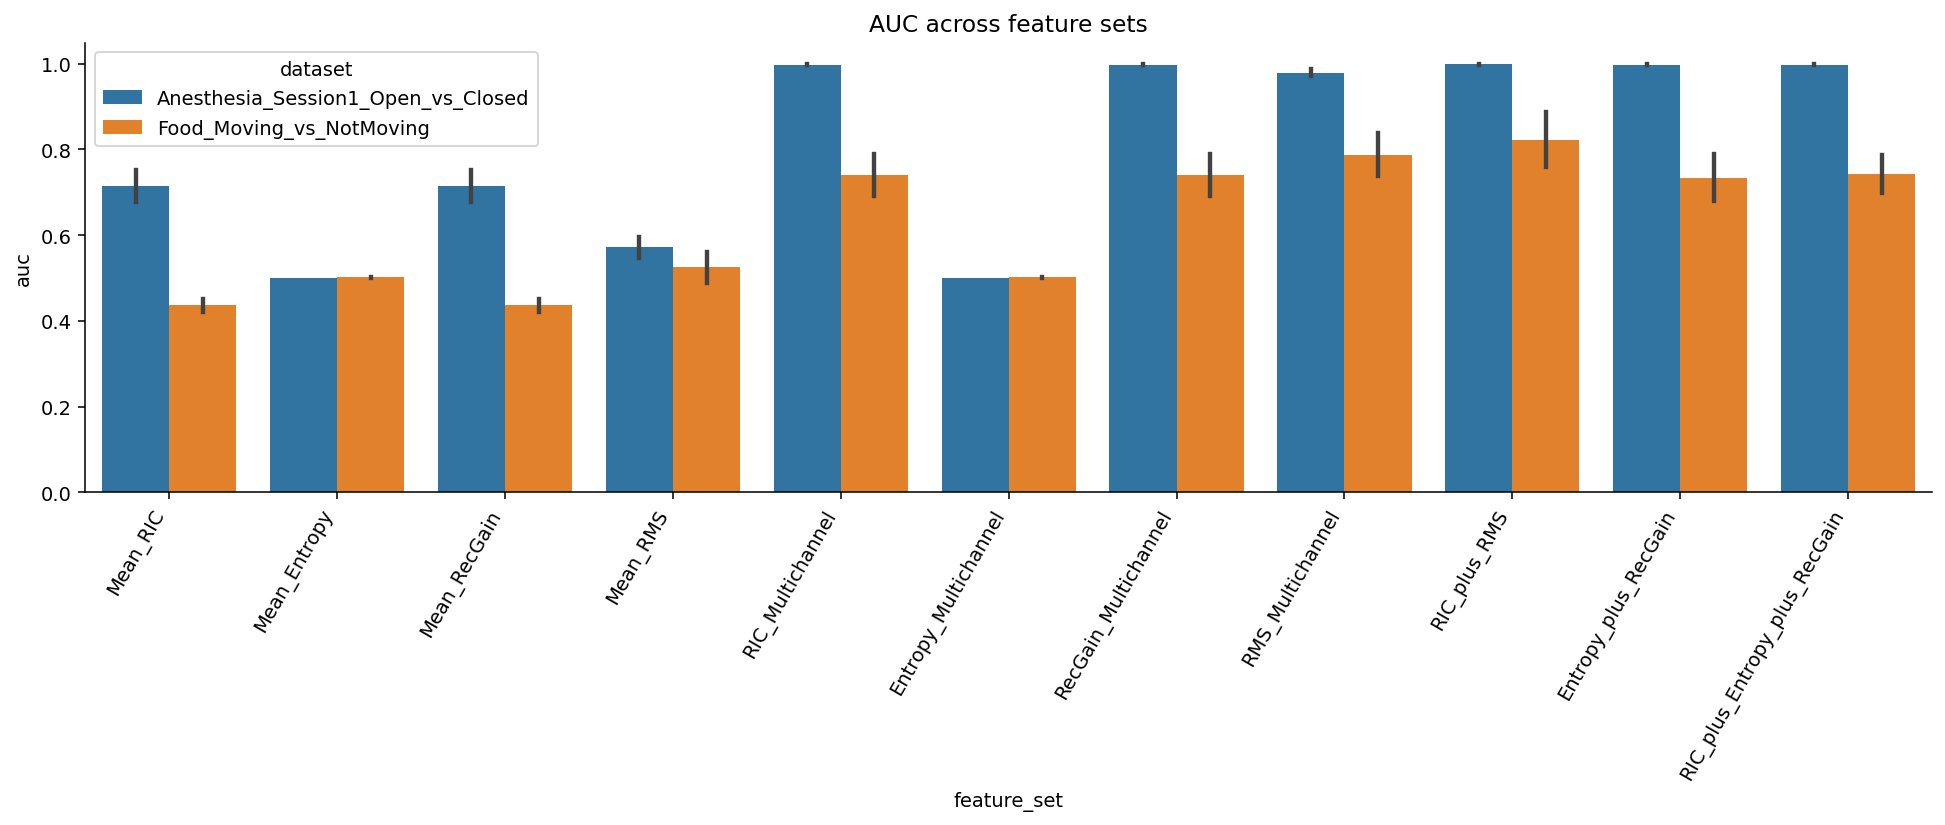

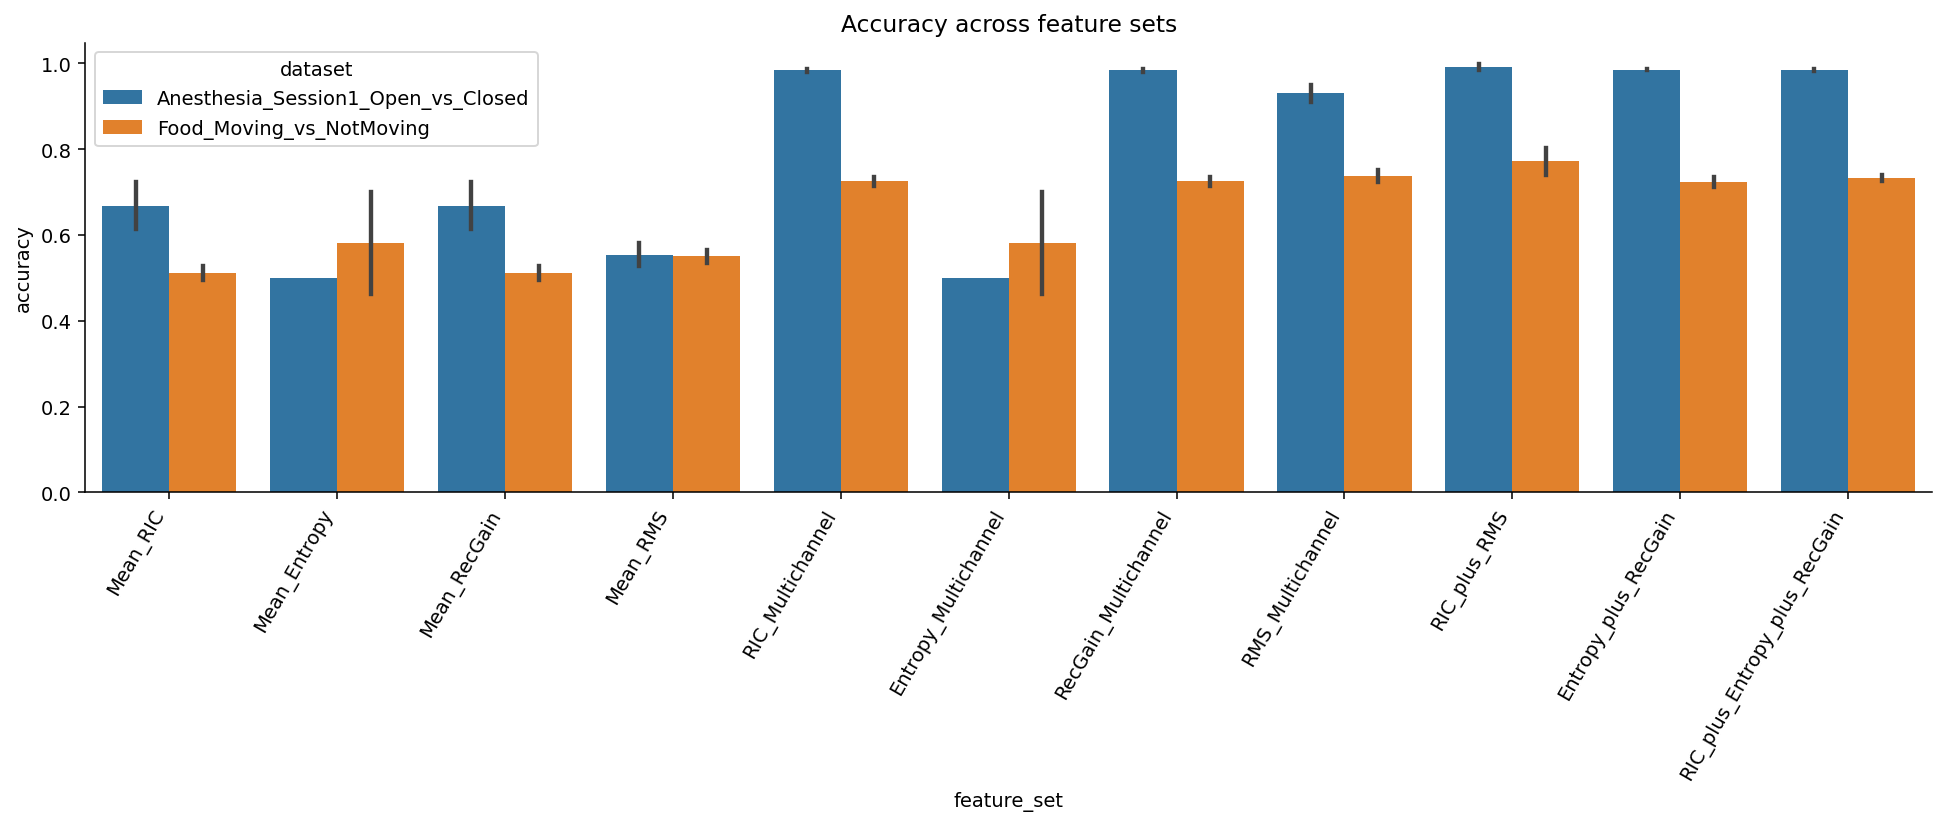

In [20]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=bench_df,
    x="feature_set",
    y="auc",
    hue="dataset"
)
plt.xticks(rotation=60, ha="right")
plt.title("AUC across feature sets")
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_auc_barplot.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=bench_df,
    x="feature_set",
    y="accuracy",
    hue="dataset"
)
plt.xticks(rotation=60, ha="right")
plt.title("Accuracy across feature sets")
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_accuracy_barplot.png", bbox_inches="tight")
plt.show()

In [21]:
def rerun_anesthesia_primary_bins(n_bins):
    r = load_anesthesia_session_v2(ANES_ROOT / "Session1", epoch_length_sec=2, n_bins=n_bins, alpha=1.0, beta=1.0)
    X = make_multichannel_feature(r["ric"][:, r["keep_mask"]])
    y = (r["labels_raw"][r["keep_mask"]] == 2).astype(int)
    model = build_models()["LogReg"]
    return evaluate_binary_model(X, y, model, cv=10)

def rerun_food_bins(n_bins):
    r = load_food_dataset_v2(FOOD_ROOT, wrist_marker_index=2, epoch_length_sec=2, n_bins=n_bins, alpha=1.0, beta=1.0)
    keep = r["keep_mask"]
    X = make_multichannel_feature(r["ric"][:, keep])
    y = r["labels_raw"][keep].astype(int)
    model = build_models()["LogReg"]
    return evaluate_binary_model(X, y, model, cv=10)

bin_rows = []
for nb in [4, 6, 8]:
    ma = rerun_anesthesia_primary_bins(nb)
    mf = rerun_food_bins(nb)
    bin_rows.append({
        "dataset": "Anesthesia_Session1_Open_vs_Closed",
        "n_bins": nb,
        "accuracy": ma["accuracy"],
        "auc": ma["auc"]
    })
    bin_rows.append({
        "dataset": "Food_Moving_vs_NotMoving",
        "n_bins": nb,
        "accuracy": mf["accuracy"],
        "auc": mf["auc"]
    })

bin_sens_df = pd.DataFrame(bin_rows)
bin_sens_df.to_csv(TAB_DIR / "sensitivity_bins.csv", index=False)
bin_sens_df

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

,dataset,n_bins,accuracy,auc
0,Anesthesia_Session1_Open_vs_Closed,4,0.981953,0.996989
1,Food_Moving_vs_NotMoving,4,0.733591,0.752656
2,Anesthesia_Session1_Open_vs_Closed,6,0.987261,0.997593
3,Food_Moving_vs_NotMoving,6,0.735521,0.788515
4,Anesthesia_Session1_Open_vs_Closed,8,0.989384,0.998219
5,Food_Moving_vs_NotMoving,8,0.774131,0.819256


In [22]:
def rerun_anesthesia_primary_epochlen(epoch_sec):
    r = load_anesthesia_session_v2(ANES_ROOT / "Session1", epoch_length_sec=epoch_sec, n_bins=6, alpha=1.0, beta=1.0)
    X = make_multichannel_feature(r["ric"][:, r["keep_mask"]])
    y = (r["labels_raw"][r["keep_mask"]] == 2).astype(int)
    model = build_models()["LogReg"]
    return evaluate_binary_model(X, y, model, cv=10)

def rerun_food_epochlen(epoch_sec):
    r = load_food_dataset_v2(FOOD_ROOT, wrist_marker_index=2, epoch_length_sec=epoch_sec, n_bins=6, alpha=1.0, beta=1.0)
    keep = r["keep_mask"]
    X = make_multichannel_feature(r["ric"][:, keep])
    y = r["labels_raw"][keep].astype(int)
    model = build_models()["LogReg"]
    return evaluate_binary_model(X, y, model, cv=10)

epoch_rows = []
for ep_sec in [1, 2, 4]:
    ma = rerun_anesthesia_primary_epochlen(ep_sec)
    mf = rerun_food_epochlen(ep_sec)
    epoch_rows.append({
        "dataset": "Anesthesia_Session1_Open_vs_Closed",
        "epoch_sec": ep_sec,
        "accuracy": ma["accuracy"],
        "auc": ma["auc"]
    })
    epoch_rows.append({
        "dataset": "Food_Moving_vs_NotMoving",
        "epoch_sec": ep_sec,
        "accuracy": mf["accuracy"],
        "auc": mf["auc"]
    })

epoch_sens_df = pd.DataFrame(epoch_rows)
epoch_sens_df.to_csv(TAB_DIR / "sensitivity_epoch_length.csv", index=False)
epoch_sens_df

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

Loading Session1 channels:   0%|          | 0/128 [00:00<?, ?it/s]

Loading food-tracking channels:   0%|          | 0/64 [00:00<?, ?it/s]

,dataset,epoch_sec,accuracy,auc
0,Anesthesia_Session1_Open_vs_Closed,1,0.967605,0.994367
1,Food_Moving_vs_NotMoving,1,0.658301,0.676714
2,Anesthesia_Session1_Open_vs_Closed,2,0.987261,0.997593
3,Food_Moving_vs_NotMoving,2,0.735521,0.788515
4,Anesthesia_Session1_Open_vs_Closed,4,0.991489,0.999312
5,Food_Moving_vs_NotMoving,4,0.722008,0.736011


In [23]:
bench_df.groupby("dataset")[["feature_set","model","accuracy","balanced_accuracy","f1","auc"]].apply(lambda x: x.sort_values("auc", ascending=False).head(5))

feature_set  \
dataset                                                                
Anesthesia_Session1_Open_vs_Closed 17                   RIC_plus_RMS   
                                   19           Entropy_plus_RecGain   
                                   9                RIC_Multichannel   
                                   13           RecGain_Multichannel   
                                   21  RIC_plus_Entropy_plus_RecGain   
Food_Moving_vs_NotMoving           38                   RIC_plus_RMS   
                                   36               RMS_Multichannel   
                                   40           Entropy_plus_RecGain   
                                   30               RIC_Multichannel   
                                   34           RecGain_Multichannel   

                                              model  accuracy  \
dataset                                                         
Anesthesia_Session1_Open_vs_Closed 17  RandomForest  0.985138   
                                   19  RandomForest  0.983015   
                                   9   RandomForest  0.979830   
                                   13  RandomForest  0.979830   
                                   21  RandomForest  0.981953   
Food_Moving_vs_NotMoving           38        LogReg  0.803089   
                                   36        LogReg  0.750965   
                                   40        LogReg  0.735521   
                                   30        LogReg  0.735521   
                                   34        LogReg  0.735521   

                                       balanced_accuracy        f1       auc  
dataset                                                                       
Anesthesia_Session1_Open_vs_Closed 17           0.985138  0.985106  0.998936  
                                   19           0.983015  0.982979  0.998109  
                                   9            0.979830  0.979809  0.998098  
                                   13           0.979830  0.979809  0.998098  
                                   21           0.981953  0.981934  0.998080  
Food_Moving_vs_NotMoving           38           0.787983  0.696429  0.886616  
                                   36           0.747043  0.640669  0.838079  
                                   40           0.726873  0.616246  0.788515  
                                   30           0.726873  0.616246  0.788515  
                                   34           0.726873  0.616246  0.788515

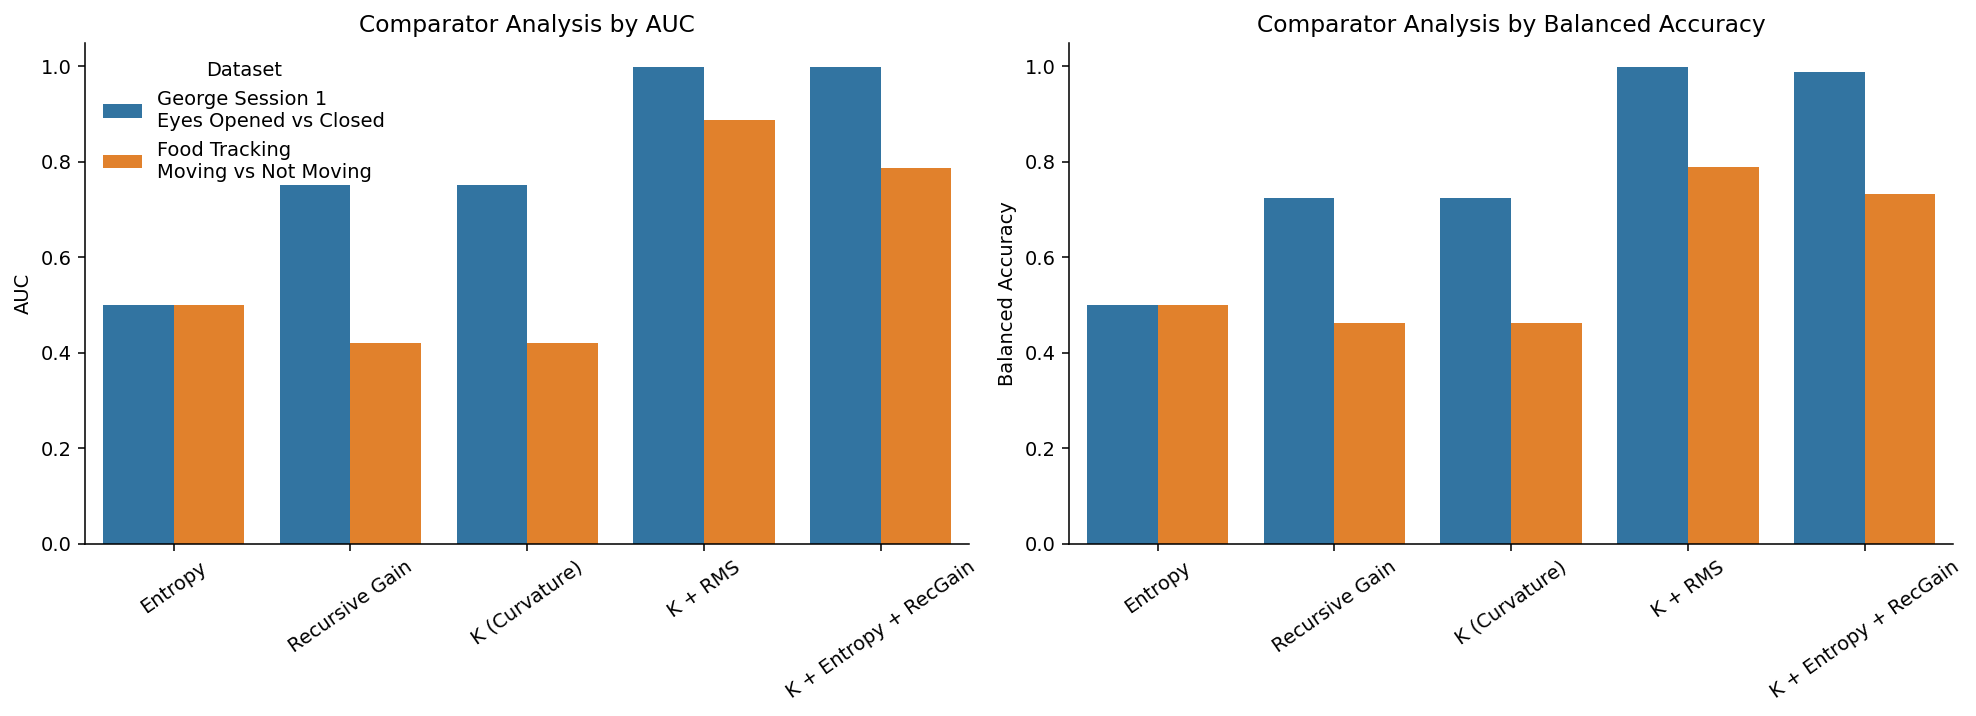

Saved to:
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure_Ablation_Comparator.png
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure_Ablation_Comparator.tiff


In [24]:
# Comparator / ablation figure for the manuscript

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Keep only the clearest comparator feature sets
plot_df = bench_df.copy()
plot_df = plot_df[
    plot_df["feature_set"].isin([
        "Mean_Entropy",
        "Mean_RecGain",
        "Mean_RIC",
        "RIC_plus_RMS",
        "RIC_plus_Entropy_plus_RecGain"
    ])
].copy()

# Use only the better-performing linear model for a cleaner figure
plot_df = plot_df[plot_df["model"] == "LogReg"].copy()

# Rename features for publication-ready labels
label_map = {
    "Mean_Entropy": "Entropy",
    "Mean_RecGain": "Recursive Gain",
    "Mean_RIC": "K (Curvature)",
    "RIC_plus_RMS": "K + RMS",
    "RIC_plus_Entropy_plus_RecGain": "K + Entropy + RecGain"
}
plot_df["Feature"] = plot_df["feature_set"].map(label_map)

dataset_map = {
    "Anesthesia_Session1_Open_vs_Closed": "George Session 1\nEyes Opened vs Closed",
    "Food_Moving_vs_NotMoving": "Food Tracking\nMoving vs Not Moving"
}
plot_df["Dataset"] = plot_df["dataset"].map(dataset_map)

feature_order = [
    "Entropy",
    "Recursive Gain",
    "K (Curvature)",
    "K + RMS",
    "K + Entropy + RecGain"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=plot_df,
    x="Feature",
    y="auc",
    hue="Dataset",
    order=feature_order,
    ax=axes[0]
)
axes[0].set_title("Comparator Analysis by AUC")
axes[0].set_ylabel("AUC")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=plot_df,
    x="Feature",
    y="balanced_accuracy",
    hue="Dataset",
    order=feature_order,
    ax=axes[1]
)
axes[1].set_title("Comparator Analysis by Balanced Accuracy")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

# Keep only one legend
axes[1].legend_.remove()
axes[0].legend(title="Dataset", frameon=False)

# Save high-resolution output
fig_path_png = FIG_DIR / "Figure_Ablation_Comparator.png"
fig_path_tiff = FIG_DIR / "Figure_Ablation_Comparator.tiff"

plt.savefig(fig_path_png, dpi=600, bbox_inches="tight")
plt.savefig(fig_path_tiff, dpi=600, bbox_inches="tight")
plt.show()

print("Saved to:")
print(fig_path_png)
print(fig_path_tiff)

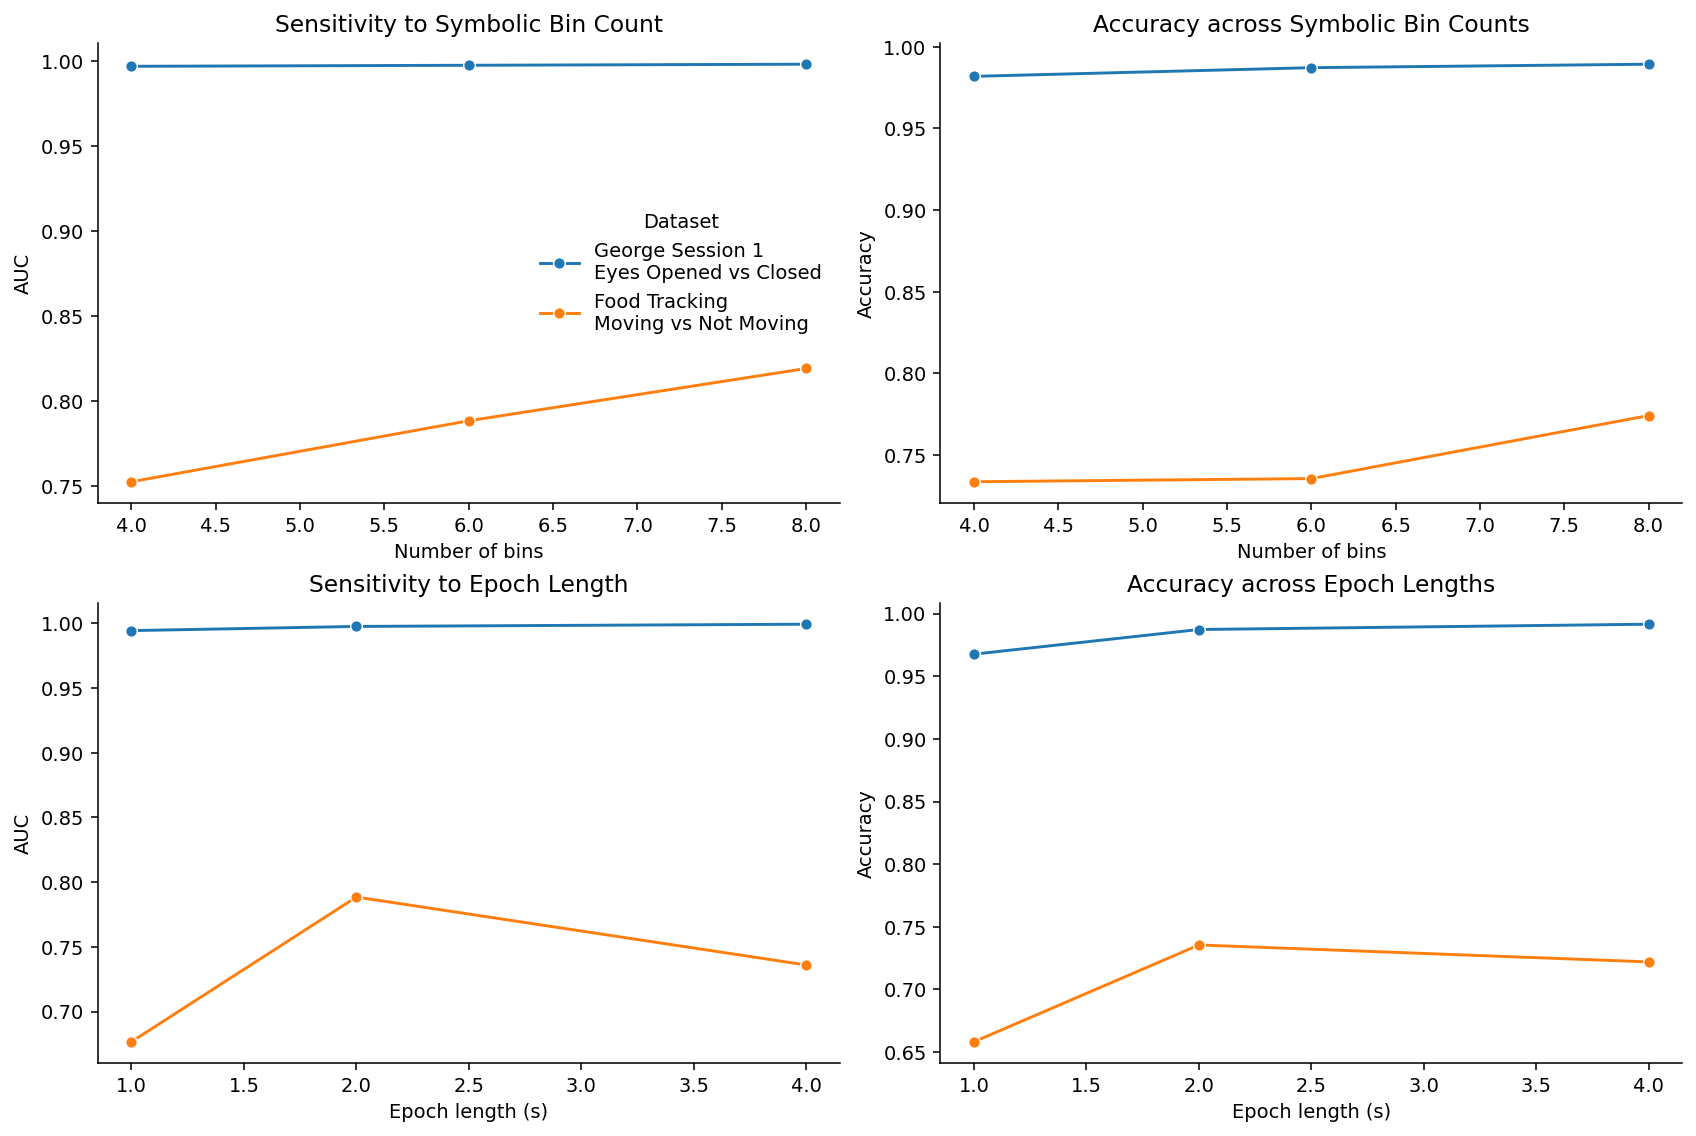

Saved to:
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure_Sensitivity_Bins_Epochs.png
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure_Sensitivity_Bins_Epochs.tiff


In [25]:
# Optional supplementary figure: sensitivity across symbolic bins and epoch length

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Clean dataset labels for plotting
bin_plot = bin_sens_df.copy()
epoch_plot = epoch_sens_df.copy()

dataset_map = {
    "Anesthesia_Session1_Open_vs_Closed": "George Session 1\nEyes Opened vs Closed",
    "Food_Moving_vs_NotMoving": "Food Tracking\nMoving vs Not Moving"
}

bin_plot["Dataset"] = bin_plot["dataset"].map(dataset_map)
epoch_plot["Dataset"] = epoch_plot["dataset"].map(dataset_map)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# AUC vs number of bins
sns.lineplot(
    data=bin_plot,
    x="n_bins",
    y="auc",
    hue="Dataset",
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sensitivity to Symbolic Bin Count")
axes[0, 0].set_xlabel("Number of bins")
axes[0, 0].set_ylabel("AUC")

# Accuracy vs number of bins
sns.lineplot(
    data=bin_plot,
    x="n_bins",
    y="accuracy",
    hue="Dataset",
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Accuracy across Symbolic Bin Counts")
axes[0, 1].set_xlabel("Number of bins")
axes[0, 1].set_ylabel("Accuracy")

# AUC vs epoch length
sns.lineplot(
    data=epoch_plot,
    x="epoch_sec",
    y="auc",
    hue="Dataset",
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Sensitivity to Epoch Length")
axes[1, 0].set_xlabel("Epoch length (s)")
axes[1, 0].set_ylabel("AUC")

# Accuracy vs epoch length
sns.lineplot(
    data=epoch_plot,
    x="epoch_sec",
    y="accuracy",
    hue="Dataset",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Accuracy across Epoch Lengths")
axes[1, 1].set_xlabel("Epoch length (s)")
axes[1, 1].set_ylabel("Accuracy")

# Keep only one legend
axes[0, 1].legend_.remove()
axes[1, 0].legend_.remove()
axes[1, 1].legend_.remove()
axes[0, 0].legend(title="Dataset", frameon=False)

fig_path_png = FIG_DIR / "Figure_Sensitivity_Bins_Epochs.png"
fig_path_tiff = FIG_DIR / "Figure_Sensitivity_Bins_Epochs.tiff"

plt.savefig(fig_path_png, dpi=600, bbox_inches="tight")
plt.savefig(fig_path_tiff, dpi=600, bbox_inches="tight")
plt.show()

print("Saved to:")
print(fig_path_png)
print(fig_path_tiff)

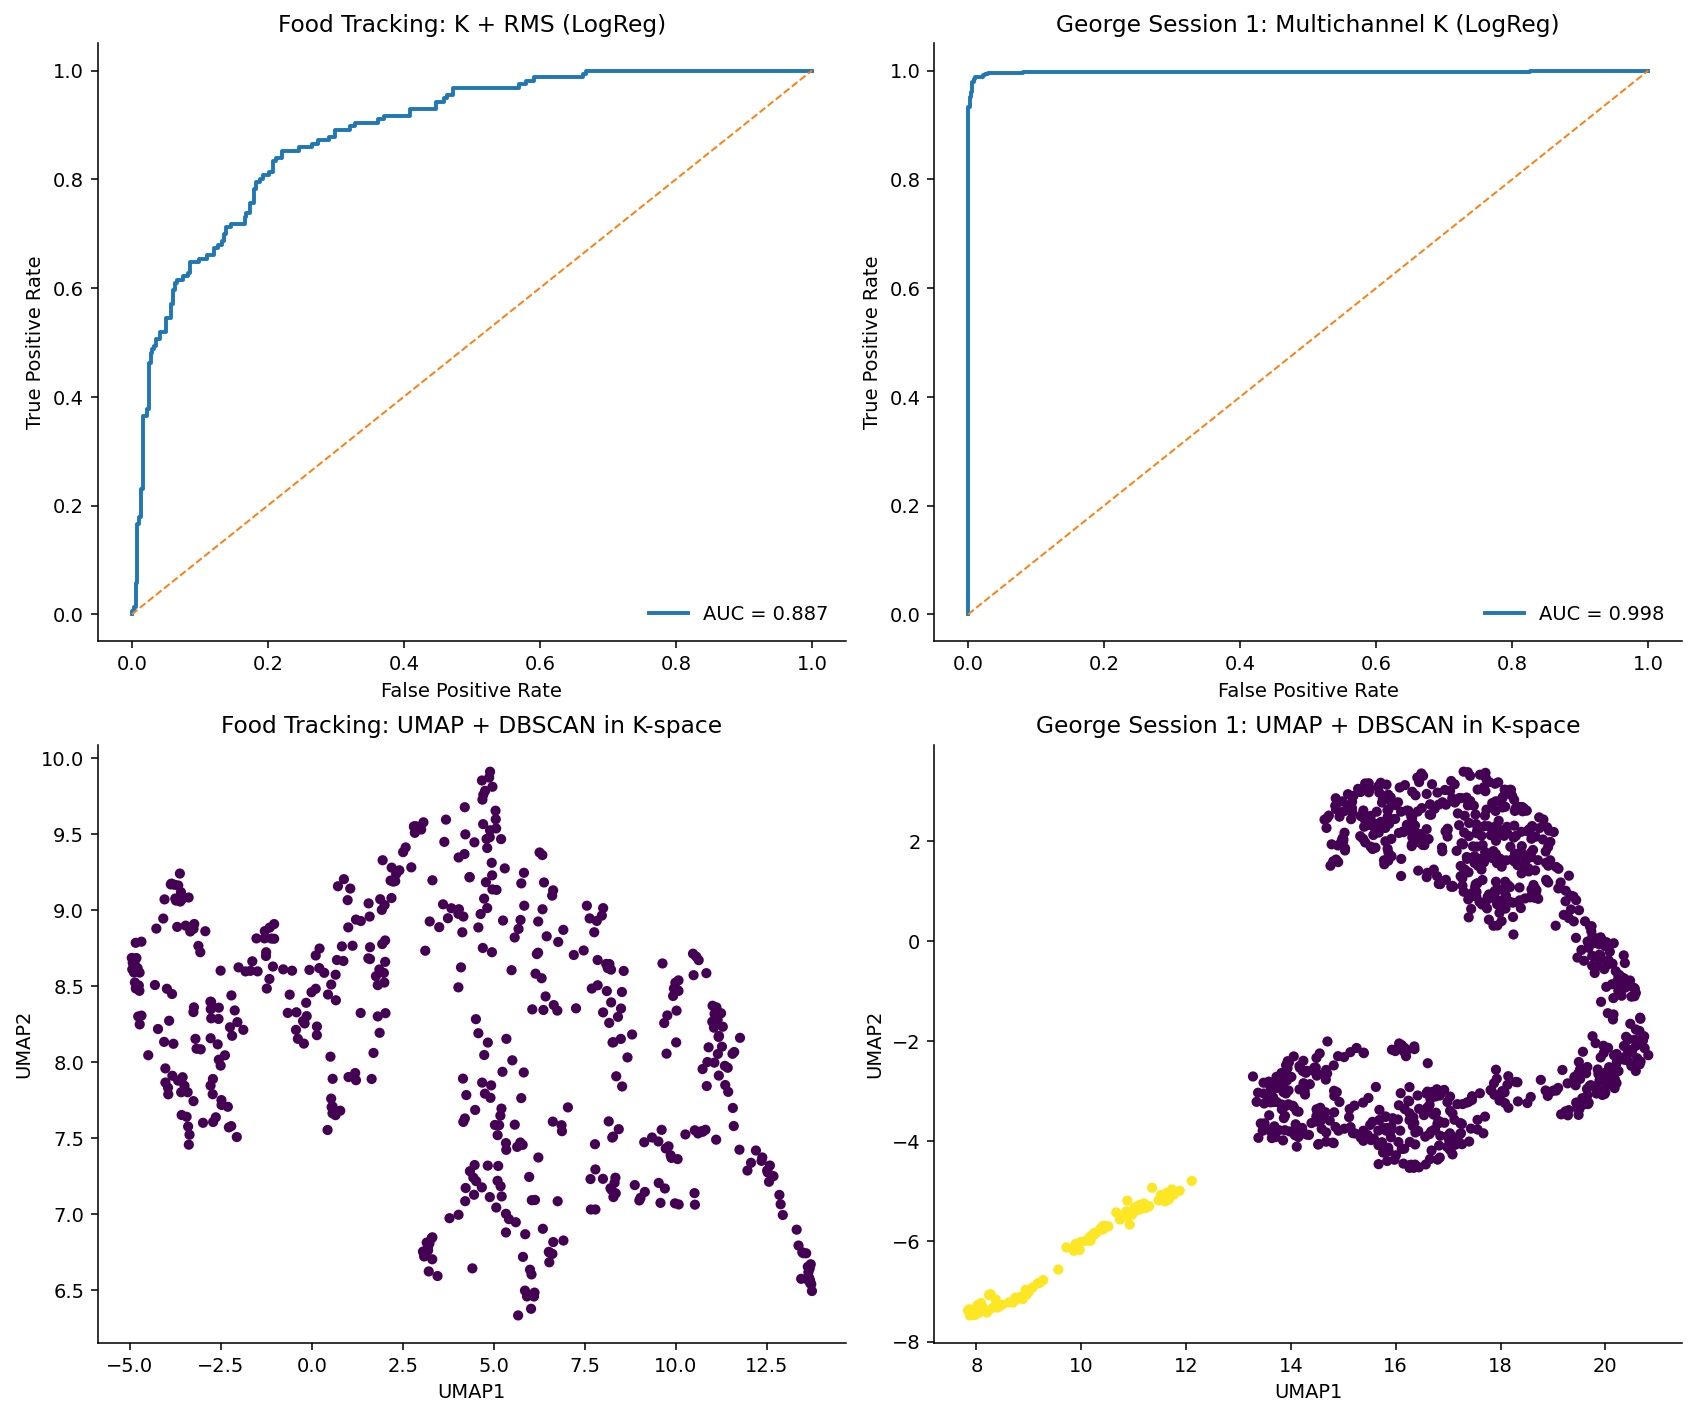

Saved to:
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure5_corrected_ROC_UMAP.png
C:\Users\mahsa\Downloads\Cleaned_data_for_ecog\ric_outputs\figures\Figure5_corrected_ROC_UMAP.tiff
Food AUC = 0.887
George AUC = 0.998


In [26]:
# Corrected Figure 5: ROC + UMAP/DBSCAN using updated pipeline results

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import DBSCAN
import umap.umap_ as umap

# -------------------------
# Helper feature builders
# -------------------------
def make_multichannel_feature(X_channel_epoch):
    return X_channel_epoch.T

def concat_features(*arrays_2d):
    return np.concatenate(arrays_2d, axis=1)

# -------------------------
# Build corrected figure-5 feature sets
# Top row:
#   Food  = K + RMS (LogReg)   [updated best model]
#   George = multichannel K (LogReg)
# Bottom row:
#   UMAP on multichannel K for both datasets
# -------------------------
X_food_cls = concat_features(
    make_multichannel_feature(food_all["ric"]),
    make_multichannel_feature(food_all["rms"])
)
y_food = food_all["y"].astype(int)

X_george_cls = make_multichannel_feature(anesthesia_primary["ric"])
y_george = anesthesia_primary["y"].astype(int)

X_food_umap = make_multichannel_feature(food_all["ric"])
X_george_umap = make_multichannel_feature(anesthesia_primary["ric"])

# -------------------------
# Models
# -------------------------
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# Cross-validated ROC scores
food_scores = cross_val_predict(clf, X_food_cls, y_food, cv=cv, method="predict_proba")[:, 1]
george_scores = cross_val_predict(clf, X_george_cls, y_george, cv=cv, method="predict_proba")[:, 1]

fpr_food, tpr_food, _ = roc_curve(y_food, food_scores)
fpr_george, tpr_george, _ = roc_curve(y_george, george_scores)

auc_food = auc(fpr_food, tpr_food)
auc_george = auc(fpr_george, tpr_george)

# -------------------------
# UMAP + DBSCAN on K-space
# -------------------------
def run_umap_dbscan(X, n_neighbors=15, min_dist=0.1, eps=0.8, min_samples=5):
    Xs = StandardScaler().fit_transform(X)
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=SEED
    )
    emb = reducer.fit_transform(Xs)

    clusterer = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = clusterer.fit_predict(emb)
    return emb, clusters

emb_food, clusters_food = run_umap_dbscan(X_food_umap)
emb_george, clusters_george = run_umap_dbscan(X_george_umap)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Top-left: Food ROC
axes[0, 0].plot(fpr_food, tpr_food, lw=2, label=f"AUC = {auc_food:.3f}")
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", lw=1)
axes[0, 0].set_title("Food Tracking: K + RMS (LogReg)")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend(frameon=False, loc="lower right")

# Top-right: George ROC
axes[0, 1].plot(fpr_george, tpr_george, lw=2, label=f"AUC = {auc_george:.3f}")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", lw=1)
axes[0, 1].set_title("George Session 1: Multichannel K (LogReg)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(frameon=False, loc="lower right")

# Bottom-left: Food UMAP clusters
sc1 = axes[1, 0].scatter(
    emb_food[:, 0],
    emb_food[:, 1],
    c=clusters_food,
    s=18
)
axes[1, 0].set_title("Food Tracking: UMAP + DBSCAN in K-space")
axes[1, 0].set_xlabel("UMAP1")
axes[1, 0].set_ylabel("UMAP2")

# Bottom-right: George UMAP clusters
sc2 = axes[1, 1].scatter(
    emb_george[:, 0],
    emb_george[:, 1],
    c=clusters_george,
    s=18
)
axes[1, 1].set_title("George Session 1: UMAP + DBSCAN in K-space")
axes[1, 1].set_xlabel("UMAP1")
axes[1, 1].set_ylabel("UMAP2")

# Save
fig_path_png = FIG_DIR / "Figure5_corrected_ROC_UMAP.png"
fig_path_tiff = FIG_DIR / "Figure5_corrected_ROC_UMAP.tiff"

plt.savefig(fig_path_png, dpi=600, bbox_inches="tight")
plt.savefig(fig_path_tiff, dpi=600, bbox_inches="tight")
plt.show()

print("Saved to:")
print(fig_path_png)
print(fig_path_tiff)
print(f"Food AUC = {auc_food:.3f}")
print(f"George AUC = {auc_george:.3f}")